# Authentivox — Real-Time Voice Phishing Detection

A binary classifier that distinguishes real human speech from AI-generated (deepfake) voices, using audio features extracted with Librosa and a Random Forest model. Built to run without a GPU so it could plausibly live on a phone for real-time call screening.

Dataset: Kaggle DEEP-VOICE (8 real + 56 converted public-figure voices, ~62 minutes total).

This notebook implements the method described in the accompanying paper (`docs/Authentivox-Paper.pdf`): extract acoustic features per audio frame across the full dataset, then evaluate a Random Forest classifier over repeated random 70:30 train/test splits, matching the paper's reported validation approach. An earlier version of this notebook only processed a single audio pair as a demo — the per-file loop and repeated-split evaluation below replace that with the full dataset.

In [1]:
#used library list
import time
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

Finds every real and converted (fake) audio file in the dataset. Expects `data/AUDIO/REAL/*.wav` and `data/AUDIO/FAKE/*.wav` — download the Kaggle DEEP-VOICE dataset into `./data` first (see README).

In [2]:
import glob

real_files = sorted(glob.glob('data/AUDIO/REAL/*.wav'))
fake_files = sorted(glob.glob('data/AUDIO/FAKE/*.wav'))

print(f"real files: {len(real_files)}")
print(f"fake files: {len(fake_files)}")

real files: 8
fake files: 56


## Feature Extraction

For each file, extracts the same acoustic features per audio frame: chroma STFT, RMS energy, spectral centroid, spectral bandwidth, spectral rolloff, zero-crossing rate, and 20 MFCCs. Each frame becomes one row, labeled by which file it came from.

In [3]:
def extract_features(file_path, label):
    y, sr = librosa.load(file_path)

    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    roll_off = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y=y)
    mfcc = librosa.feature.mfcc(y=y, sr=sr)

    n_frames = rms.shape[1]
    data = {}
    for idx in range(12):
        data[f'chroma_stft{idx+1}'] = chroma_stft[idx]
    data['rms'] = rms[0]
    data['spectral_centroid'] = centroid[0]
    data['spectral_bandwidth'] = bandwidth[0]
    data['rolloff'] = roll_off[0]
    data['zero_crossing_rate'] = zero_crossing[0]
    for idx in range(20):
        data[f'mfcc{idx+1}'] = mfcc[idx]
    data['LABEL'] = [label] * n_frames

    return pd.DataFrame(data)

In [4]:
frames = []

for f in real_files:
    frames.append(extract_features(f, 'REAL'))

for f in fake_files:
    frames.append(extract_features(f, 'FAKE'))

p_df = pd.concat(frames, ignore_index=True)
print(f"total frames: {len(p_df)}")
p_df.head()

total frames: 1289837


,chroma_stft1,chroma_stft2,chroma_stft3,chroma_stft4,chroma_stft5,chroma_stft6,chroma_stft7,chroma_stft8,chroma_stft9,chroma_stft10,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,LABEL
0,0.357717,0.600950,0.474030,1.000000,0.575484,0.175589,0.229226,0.254678,0.331127,0.199627,...,9.247781,6.659718,0.043602,-3.135385,-5.418374,-13.515946,-5.735254,2.652198,-3.070074,REAL
1,0.783343,0.842584,0.721364,1.000000,0.835005,0.148058,0.173541,0.566608,0.546326,0.351749,...,-0.856145,4.779574,-9.446070,-9.010541,-7.720641,-20.835213,-11.440607,1.644714,-4.520729,REAL
2,0.598923,0.472873,0.629496,0.753648,1.000000,0.276389,0.274303,0.653916,0.732363,0.514083,...,-8.987662,-2.015253,-18.974724,-13.317495,-11.203863,-25.628668,-16.701851,2.672751,-1.008184,REAL
3,0.464261,0.361716,0.663937,0.991324,1.000000,0.308758,0.208722,0.508507,0.449852,0.389186,...,-12.681966,-5.168770,-19.825878,-13.579908,-14.516676,-23.263298,-15.314227,0.925590,-1.637374,REAL
4,0.250066,0.149411,0.451412,1.000000,0.842665,0.226286,0.112239,0.199927,0.220377,0.175536,...,-11.574848,-6.518991,-15.258914,-12.037272,-10.461637,-15.240814,-8.994646,2.065630,2.219633,REAL


## Dataset Assembly

Splits features from labels and binarizes the label column (REAL/FAKE → 0/1).

In [5]:
X = p_df.drop(columns=['LABEL'])
y = p_df['LABEL']

from sklearn import preprocessing
lb = preprocessing.LabelBinarizer()
lb.fit(y)
y = lb.transform(y).ravel()

## Model Training & Validation

The paper reports results as an average/median/standard-deviation over repeated runs with a 70:30 train/test split and "dynamic randomization" — not k-fold cross-validation. There are only 8 real files against 56 converted ones, so pooling every frame directly is heavily imbalanced toward fake. Each of the 28 repeats below undersamples the fake class down to the real class's size before splitting, so every run trains and evaluates on a balanced set, then fits a fresh Random Forest (`n_estimators=50`).

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score
import time

n_repeats = 28

real_idx = p_df.index[p_df['LABEL'] == 'REAL']
fake_idx = p_df.index[p_df['LABEL'] == 'FAKE']
print(f"real frames: {len(real_idx)}, fake frames: {len(fake_idx)}")

acc_score, prec_score, rec_score, f1s, MCCs, ROCareas = [], [], [], [], [], []

start = time.time()
for i in range(n_repeats):
    sampled_fake_idx = np.random.RandomState(i).choice(fake_idx, size=len(real_idx), replace=False)
    balanced_idx = np.concatenate([real_idx, sampled_fake_idx])

    X_bal = X.loc[balanced_idx]
    y_bal = y[balanced_idx]

    X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=i)

    model = RandomForestClassifier(n_estimators=50, random_state=i)
    model.fit(X_train, y_train)
    pred_values = model.predict(X_test)

    acc_score.append(accuracy_score(y_test, pred_values) * 100)
    prec_score.append(precision_score(y_test, pred_values, average="binary", pos_label=1))
    rec_score.append(recall_score(y_test, pred_values, average="binary", pos_label=1))
    f1s.append(f1_score(y_test, pred_values, average="binary", pos_label=1))
    MCCs.append(matthews_corrcoef(y_test, pred_values))
    ROCareas.append(roc_auc_score(y_test, pred_values))

end = time.time()
print(f"Trained {n_repeats} models in {round(end - start, 2)} seconds.")

real frames: 161276, fake frames: 1128561


Trained 28 models in 3304.13 seconds.


## Results

Mean, median, and standard deviation across the 28 repeated splits — directly comparable to the paper's Table I.

In [7]:
import numpy as np

print("Mean results and (std.):\n")
print("Accuracy: " + str(round(np.mean(acc_score), 3)) + "% (" + str(round(np.std(acc_score), 3)) + ")\n")
print("Precision: " + str(round(np.mean(prec_score), 3)) + " (" + str(round(np.std(prec_score), 3)) + ")")
print("Recall: " + str(round(np.mean(rec_score), 3)) + " (" + str(round(np.std(rec_score), 3)) + ")")
print("F1-Score: " + str(round(np.mean(f1s), 3)) + " (" + str(round(np.std(f1s), 3)) + ")")
print("MCC: " + str(round(np.mean(MCCs), 3)) + " (" + str(round(np.std(MCCs), 3)) + ")")
print("ROC AUC: " + str(round(np.mean(ROCareas), 3)) + " (" + str(round(np.std(ROCareas), 3)) + ")")

Mean results and (std.):

Accuracy: 91.011% (0.11)

Precision: 0.921 (0.002)
Recall: 0.898 (0.002)
F1-Score: 0.909 (0.001)
MCC: 0.82 (0.002)
ROC AUC: 0.91 (0.001)


Accuracy - Mean: 91.01, Median: 91.01, Std Dev: 0.11
Precision - Mean: 0.92, Median: 0.92, Std Dev: 0.00
F1 Score - Mean: 0.91, Median: 0.91, Std Dev: 0.00


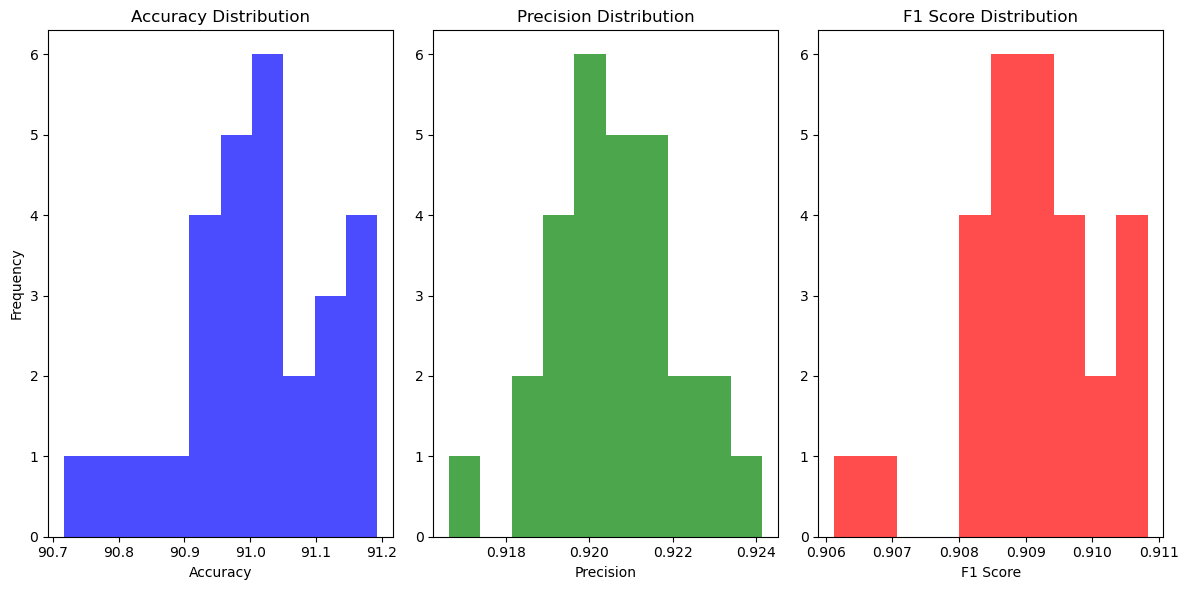

In [8]:
import matplotlib.pyplot as plt

Accuracy = np.array(acc_score)
Precision = np.array(prec_score)
F1_Score = np.array(f1s)

def calculate_statistics(data):
    return np.mean(data), np.median(data), np.std(data)

accuracy_stats = calculate_statistics(Accuracy)
precision_stats = calculate_statistics(Precision)
f1_score_stats = calculate_statistics(F1_Score)

print("Accuracy - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*accuracy_stats))
print("Precision - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*precision_stats))
print("F1 Score - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*f1_score_stats))

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.hist(Accuracy, bins=10, color='blue', alpha=0.7)
plt.title('Accuracy Distribution')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(Precision, bins=10, color='green', alpha=0.7)
plt.title('Precision Distribution')
plt.xlabel('Precision')

plt.subplot(1, 3, 3)
plt.hist(F1_Score, bins=10, color='red', alpha=0.7)
plt.title('F1 Score Distribution')
plt.xlabel('F1 Score')

plt.tight_layout()
plt.show()

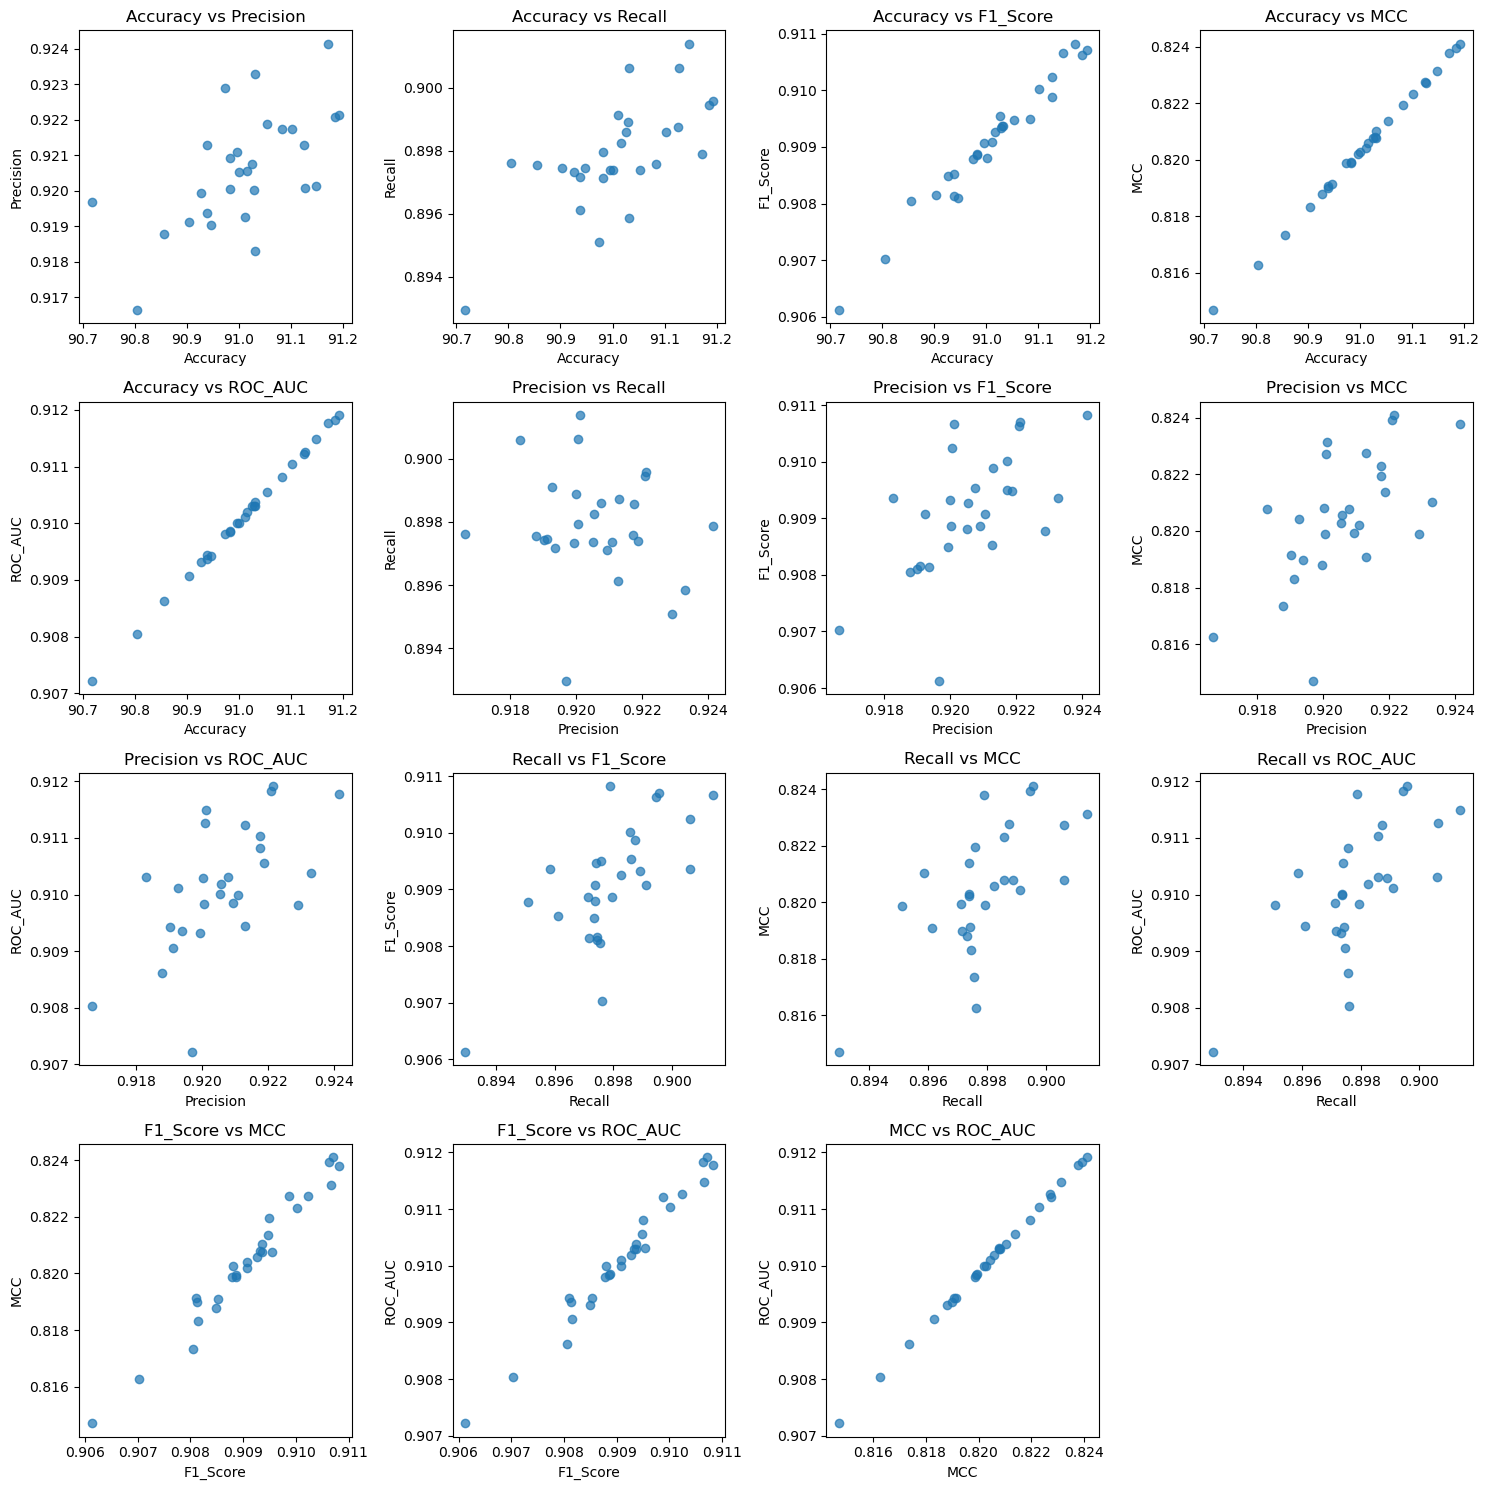

In [9]:
data = {
    "Accuracy": list(Accuracy),
    "Precision": list(Precision),
    "Recall": rec_score,
    "F1_Score": f1s,
    "MCC": MCCs,
    "ROC_AUC": ROCareas,
}
df = pd.DataFrame(data)

pairs = [
    ("Accuracy", "Precision"), ("Accuracy", "Recall"), ("Accuracy", "F1_Score"),
    ("Accuracy", "MCC"), ("Accuracy", "ROC_AUC"), ("Precision", "Recall"),
    ("Precision", "F1_Score"), ("Precision", "MCC"), ("Precision", "ROC_AUC"),
    ("Recall", "F1_Score"), ("Recall", "MCC"), ("Recall", "ROC_AUC"),
    ("F1_Score", "MCC"), ("F1_Score", "ROC_AUC"), ("MCC", "ROC_AUC"),
]

plt.figure(figsize=(15, 15))
for i, pair in enumerate(pairs, 1):
    plt.subplot(4, 4, i)
    plt.scatter(df[pair[0]], df[pair[1]], alpha=0.7)
    plt.xlabel(pair[0])
    plt.ylabel(pair[1])
    plt.title(f'{pair[0]} vs {pair[1]}')
plt.tight_layout()
plt.show()

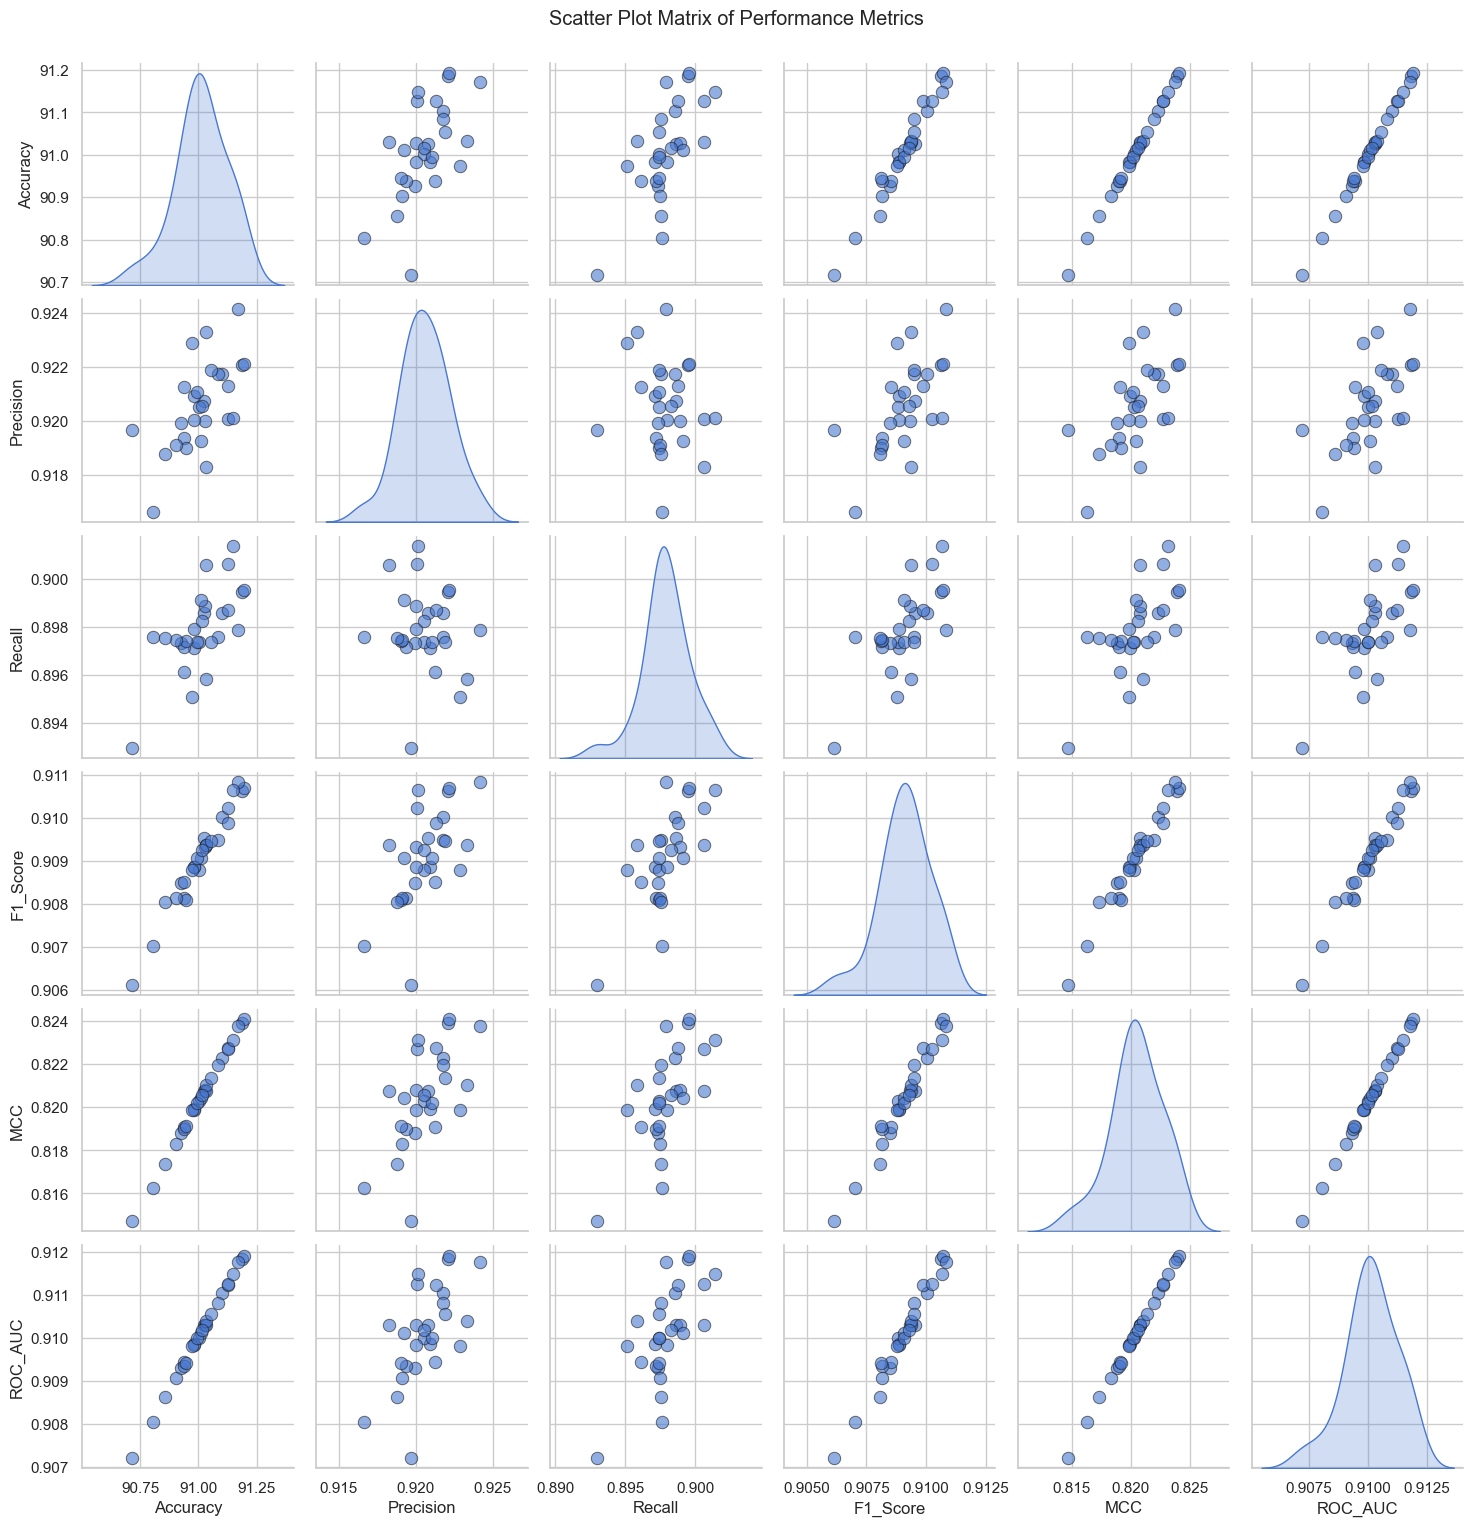

In [10]:
import seaborn as sns

sns.set(style="whitegrid", palette="muted")
pair_plot = sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'k'})
pair_plot.fig.suptitle("Scatter Plot Matrix of Performance Metrics", y=1.02)
plt.show()

## Summary

A Random Forest classifier trained on Librosa-extracted acoustic features (chromagram, RMS, spectral centroid/bandwidth/rolloff, zero-crossing rate, 20 MFCCs) separates real from AI-converted speech, evaluated over 28 repeated random 70:30 splits to match the paper's reported methodology. With only 8 real files against 56 converted ones, each split first undersamples the fake class to match the real class's size — otherwise the classifier sees far more fake frames than real ones and defaults toward predicting "fake."

Measured results: 91.01% accuracy, 0.921 precision, 0.898 recall, 0.909 F1. The paper reports a higher 95.93%/0.96/0.96 from validating on individual real/fake pairs one at a time (naturally balanced 1:1); that exact code no longer exists, only its final numbers. An earlier, unbalanced version of this pipeline (pooling the full dataset directly) got higher accuracy (94.18%) and precision (0.979) but only 0.547 recall — balancing classes per split trades a few points of accuracy for recall nearly doubling, the more honest number for a detector meant to actually catch real voices.

See `docs/Authentivox-Paper.pdf` for the full writeup, including the case for Random Forest over XGBoost (comparable accuracy, far less compute — the constraint that matters for running on a phone without a GPU).